# Kunci Jawaban - Linear Regression

- **Dataset:** [House Rent Prediction Dataset](https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset)
- **Target:** `Rent`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, scatter plot, dan boxplot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE, boxplot, dan scatter plot.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [3]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [4]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Siapkan file dataset Kaggle

Download dataset dari Kaggle, lalu letakkan file `House_Rent_Dataset.csv` di folder kerja notebook.

In [5]:
DATA_PATH = "House_Rent_Dataset.csv"

### Baca dataset CSV

Baca file CSV menjadi DataFrame bernama `df`.

In [6]:
df = pd.read_csv(DATA_PATH)

### Tentukan kolom target

Tentukan kolom `Rent` sebagai target prediksi.

In [7]:
TARGET_COL = "Rent"

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom pada dataset.

In [8]:
df.shape

(4746, 12)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki 4746 baris dan 12 kolom.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat contoh isi data.

In [9]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


> Berdasarkan lima baris pertama, kolom apa yang menjadi target prediksi?

Jawaban: Kolom target prediksi adalah `Rent`.

> Kolom mana saja yang terlihat berisi kategori atau teks?

Jawaban: Kolom seperti `Posted On`, `Floor`, `Area Type`, `Area Locality`, `City`, `Furnishing Status`, `Tenant Preferred`, dan `Point of Contact` berisi teks atau kategori.

## 3 - Data Understanding

### Tampilkan informasi dataset

Tampilkan informasi struktur dataset menggunakan `info()`.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


> Berdasarkan output `info()`, apa tipe data yang muncul pada dataset?

Jawaban: Dataset memiliki tipe data `object` dan `int64`.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak. Semua kolom memiliki 4746 non-null, sama dengan jumlah baris dataset.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [11]:
df.isna().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris duplikat penuh pada dataset.

In [12]:
df.duplicated().sum()

np.int64(0)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Jumlah baris duplikat penuh adalah 0.

### Tampilkan statistik deskriptif

Tampilkan statistik deskriptif untuk kolom numerik dan kategori.

In [13]:
df.describe(include="all")

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
count,4746,4746.000,4746.000,4746.000,4746,4746,4746,4746,4746,4746,4746.000,4746
unique,81,NaN,NaN,NaN,480,3,2235,6,3,3,NaN,3
top,2022-07-06,NaN,NaN,NaN,1 out of 2,Super Area,Bandra West,Mumbai,Semi-Furnished,Bachelors/Family,NaN,Contact Owner
freq,311,NaN,NaN,NaN,379,2446,37,972,2251,3444,NaN,3216
mean,NaN,2.084,34993.451,967.491,NaN,NaN,NaN,NaN,NaN,NaN,1.966,NaN
std,NaN,0.832,78106.413,634.202,NaN,NaN,NaN,NaN,NaN,NaN,0.885,NaN
min,NaN,1.000,1200.000,10.000,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN
25%,NaN,2.000,10000.000,550.000,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN
50%,NaN,2.000,16000.000,850.000,NaN,NaN,NaN,NaN,NaN,NaN,2.000,NaN
75%,NaN,3.000,33000.000,1200.000,NaN,NaN,NaN,NaN,NaN,NaN,2.000,NaN


> Berdasarkan statistik deskriptif, berapa rata-rata target `Rent`?

Jawaban: Rata-rata target `Rent` sekitar 34993.451.

> Berdasarkan statistik deskriptif, kategori apa yang paling sering muncul pada kolom `Point of Contact`?

Jawaban: Kategori yang paling sering muncul adalah `Contact Owner`.

## 4 - Data Cleaning

### Hapus baris duplikat

Hapus baris duplikat penuh agar data lebih bersih.

In [14]:
df_clean = df.drop_duplicates().copy()

### Reset index dataset

Reset index setelah proses cleaning.

In [15]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah proses cleaning.

In [16]:
df_clean.shape

(4746, 12)

> Berdasarkan output, berapa ukuran dataset setelah duplikat dihapus?

Jawaban: Ukuran dataset tetap 4746 baris dan 12 kolom.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat penuh setelah cleaning.

In [17]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak ada baris duplikat setelah cleaning.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Tampilkan statistik deskriptif khusus untuk target `Rent`.

In [18]:
df_clean[TARGET_COL].describe()

count      4746.000
mean      34993.451
std       78106.413
min        1200.000
25%       10000.000
50%       16000.000
75%       33000.000
max     3500000.000
Name: Rent, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Mean target sekitar 34993.451, minimum 1200.000, dan maksimum 3500000.000.

### Buat histogram target

Gunakan histogram dengan KDE untuk melihat distribusi target `Rent`.

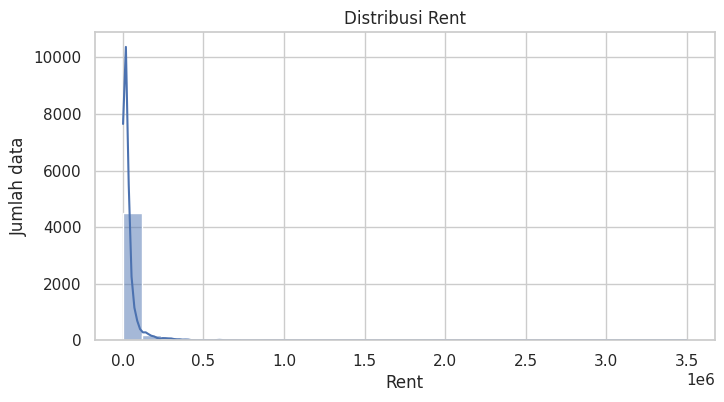

In [19]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COL], bins=30, kde=True)
plt.title("Distribusi Rent")
plt.xlabel("Rent")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan histogram, di rentang mana nilai target paling banyak muncul?

Jawaban: Nilai target paling banyak muncul pada rentang rendah, terutama sekitar 1200 sampai 117827.

> Apakah distribusi target terlihat simetris atau cenderung miring?

Jawaban: Distribusi target cenderung miring ke kanan karena ada nilai rent yang sangat tinggi.

### Hitung korelasi fitur numerik dengan target

Hitung korelasi fitur numerik terhadap target `Rent`.

In [20]:
numeric_corr = df_clean.select_dtypes(include="number").corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
numeric_corr

Bathroom   0.441
Size       0.414
BHK        0.370
Name: Rent, dtype: float64

> Berdasarkan output korelasi, fitur numerik apa yang memiliki korelasi positif paling tinggi terhadap target?

Jawaban: Fitur `Bathroom` memiliki korelasi positif paling tinggi terhadap target.

> Apakah semua fitur numerik memiliki korelasi positif terhadap target?

Jawaban: Ya. `Bathroom`, `Size`, dan `BHK` semuanya memiliki korelasi positif terhadap `Rent`.

### Buat bar plot korelasi numerik

Gunakan bar plot untuk melihat kekuatan korelasi fitur numerik dengan target.

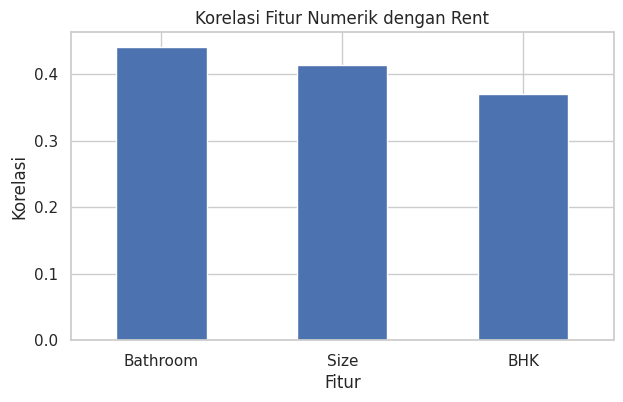

In [21]:
plt.figure(figsize=(7, 4))
numeric_corr.plot(kind="bar")
plt.title("Korelasi Fitur Numerik dengan Rent")
plt.xlabel("Fitur")
plt.ylabel("Korelasi")
plt.xticks(rotation=0)
plt.show()

> Berdasarkan bar plot, fitur numerik mana yang terlihat paling kuat hubungannya dengan target?

Jawaban: `Bathroom` terlihat paling kuat hubungannya dengan target, diikuti oleh `Size` dan `BHK`.

### Buat boxplot Rent berdasarkan City

Gunakan boxplot untuk membandingkan persebaran `Rent` pada setiap kota.

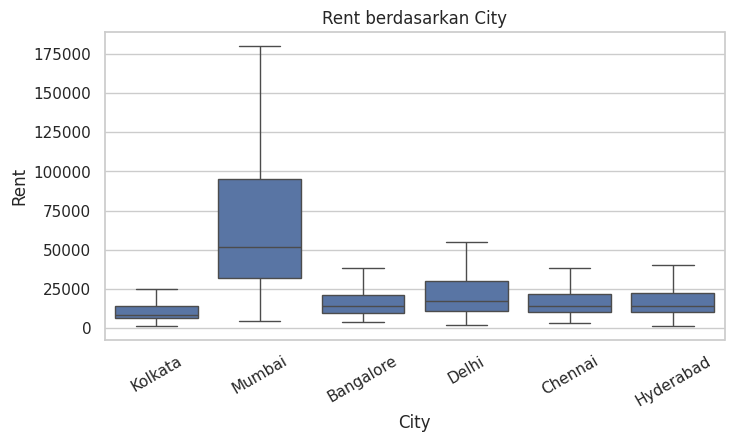

In [22]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean, x="City", y=TARGET_COL, showfliers=False)
plt.title("Rent berdasarkan City")
plt.xlabel("City")
plt.ylabel("Rent")
plt.xticks(rotation=30)
plt.show()

> Berdasarkan boxplot, kota mana yang cenderung memiliki Rent lebih tinggi?

Jawaban: `Mumbai` cenderung memiliki Rent lebih tinggi dibandingkan kota lain.

> Mengapa boxplot lebih tepat daripada scatter plot untuk kolom `City`?

Jawaban: Boxplot lebih tepat karena `City` adalah kolom kategori, sehingga lebih cocok dibaca sebagai perbandingan kelompok.

### Buat scatter plot Size dan target

Gunakan scatter plot untuk melihat hubungan `Size` dengan `Rent`.

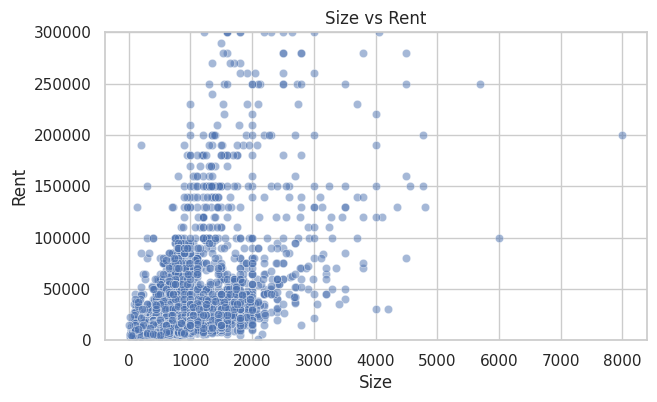

In [23]:
rent_limit = df_clean[TARGET_COL].quantile(0.99)

plt.figure(figsize=(7, 4))
sns.scatterplot(data=df_clean, x="Size", y=TARGET_COL, alpha=0.5)
plt.ylim(0, rent_limit)
plt.title("Size vs Rent")
plt.xlabel("Size")
plt.ylabel("Rent")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan `Size` dengan target?

Jawaban: Polanya cenderung positif; rumah dengan ukuran lebih besar umumnya memiliki rent lebih tinggi, walaupun sebarannya masih lebar.

> Mengapa scatter plot masih sesuai untuk kolom `Size`?

Jawaban: Scatter plot sesuai karena `Size` adalah fitur numerik dengan banyak nilai berbeda, bukan kategori dengan beberapa kelompok saja.

## 6 - Feature dan Target

### Pisahkan fitur awal

Pisahkan fitur awal dengan menghapus target dan kolom teks yang terlalu detail.

In [24]:
X_raw_model = df_clean.drop(columns=[TARGET_COL, "Posted On", "Floor", "Area Locality"])

### Pisahkan target

Simpan kolom target ke dalam variabel `y`.

In [25]:
y = df_clean[TARGET_COL]

### Encode fitur kategori

Ubah kolom kategori menjadi kolom numerik menggunakan `pd.get_dummies()`.

In [26]:
X = pd.get_dummies(X_raw_model, drop_first=True)

### Tampilkan ukuran fitur setelah encoding

Tampilkan ukuran `X` setelah kolom kategori diubah menjadi numerik.

In [27]:
X.shape

(4746, 16)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X` setelah encoding?

Jawaban: `X` memiliki 4746 baris dan 16 fitur setelah encoding.

### Tampilkan ukuran target

Tampilkan ukuran `y` sebagai target model.

In [28]:
y.shape

(4746,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki 4746 nilai target.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [29]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji sebanyak 20% dan data latih sebanyak 80%.

### Bagi data train dan test

Bagi fitur dan target menjadi data train dan data test.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Tampilkan ukuran fitur pada data train.

In [31]:
X_train.shape

(3796, 16)

### Tampilkan ukuran X_test

Tampilkan ukuran fitur pada data test.

In [32]:
X_test.shape

(950, 16)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki 3796 baris dan data test memiliki 950 baris.

## 8 - Feature Scaling

### Buat object scaler

Buat object `StandardScaler` untuk menyamakan skala fitur.

In [33]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler pada data train, lalu ubah data train ke skala standar.

In [34]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Ubah data test menggunakan scaler yang sudah di-fit pada data train.

In [35]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [36]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [37]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan?

Jawaban: Output menampilkan object `LinearRegression()`, yang berarti model berhasil dibuat dan dilatih.

### Tampilkan intercept model

Tampilkan nilai intercept dari model Linear Regression.

In [38]:
model.intercept_

np.float64(35151.516332982086)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar 35151.516.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel.

In [39]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_table

,Feature,Coefficient
1,Size,23244.582
9,City_Mumbai,20003.633
2,Bathroom,10195.103
0,BHK,3077.633
6,City_Delhi,2420.068
14,Point of Contact_Contact Builder,396.030
12,Tenant Preferred_Bachelors/Family,-344.267
8,City_Kolkata,-917.167
5,City_Chennai,-3064.200
3,Area Type_Carpet Area,-3412.719


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar?

Jawaban: Fitur `Size` memiliki koefisien positif terbesar.

> Fitur mana yang memiliki koefisien negatif terbesar arahnya?

Jawaban: Fitur `City_Hyderabad` memiliki koefisien negatif terbesar arahnya.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk membuat prediksi pada data train.

In [40]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk membuat prediksi pada data test.

In [41]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama pada data test.

In [42]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
}).head()

prediction_preview

,Actual,Predicted
0,16000,29357.745
1,12000,18642.749
2,28000,60211.060
3,8000,69398.354
4,46000,93920.653


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dengan nilai aktual?

Jawaban: Baris kedua terlihat paling dekat karena actual 12000.000 dan predicted sekitar 18642.749.

> Prediksi mana yang terlihat paling jauh dari nilai aktual?

Jawaban: Baris keempat terlihat paling jauh karena actual 8000.000 dan predicted sekitar 69398.354.

### Hitung MAE train

Hitung MAE pada data train.

In [43]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

22856.13394556974

### Hitung MAE test

Hitung MAE pada data test.

In [44]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

22232.6300440084

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar 22232.630.

### Hitung RMSE train

Hitung RMSE pada data train.

In [45]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(68800.3675667902)

### Hitung RMSE test

Hitung RMSE pada data test.

In [46]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(43717.05520963425)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar 43717.055.

### Hitung R2 train

Hitung R2 Score pada data train.

In [47]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.28586061110047145

### Hitung R2 test

Hitung R2 Score pada data test.

In [48]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.5204521815850234

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar 0.520.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 Score untuk data train dan data test.

In [49]:
evaluation_table = pd.DataFrame({
    "Data": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2 Score": [r2_train, r2_test]
})

evaluation_table

,Data,MAE,RMSE,R2 Score
0,Train,22856.134,68800.368,0.286
1,Test,22232.630,43717.055,0.520


> Berdasarkan tabel evaluasi, bagaimana perbandingan MAE train dan MAE test?

Jawaban: MAE test sekitar 2.73% lebih rendah daripada MAE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan RMSE train dan RMSE test?

Jawaban: RMSE test sekitar 36.46% lebih rendah daripada RMSE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan R2 train dan R2 test?

Jawaban: R2 test sekitar 82.07% lebih tinggi daripada R2 train.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk membandingkan nilai aktual dan prediksi pada data test.

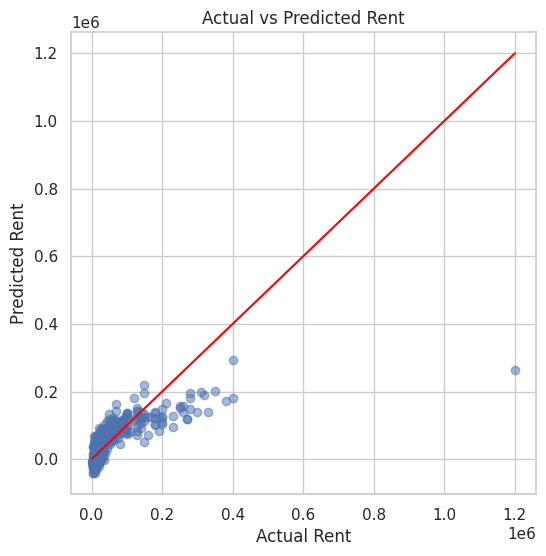

In [50]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.title("Actual vs Predicted Rent")
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.show()

## 11 - Kesimpulan

Dataset House Rent Prediction digunakan untuk memprediksi `Rent` berdasarkan ukuran rumah, jumlah kamar, kota, furnishing, tenant preference, dan point of contact. Dataset memiliki 4746 baris dan 12 kolom. Data tidak memiliki missing value dan memiliki 0 baris duplikat penuh.

EDA menunjukkan bahwa target `Rent` cenderung miring ke kanan. Fitur numerik yang paling kuat hubungannya dengan target adalah `Bathroom`, dan kota dengan rent yang cenderung lebih tinggi adalah `Mumbai`. Kolom kategori diubah menjadi numerik menggunakan `pd.get_dummies()`, sedangkan kolom `Posted On`, `Floor`, dan `Area Locality` dihapus sebelum modeling.

Data dibagi menjadi 80% data train dan 20% data test. Berdasarkan evaluasi, MAE test bernilai sekitar 22232.630, RMSE test sekitar 43717.055, dan R2 test sekitar 0.520.